In [ ]:
import os
import zipfile
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

# --- Config ---
BASE_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti"
DEST_DIR = "/content/kitti"          # change to a Drive path to persist across sessions
MAX_WORKERS = 4                       # concurrent downloads; S3 handles this fine
DELETE_ZIP_AFTER_EXTRACT = True

FILES = [
    # Object detection benchmark
    "data_object_image_2.zip",
    "data_object_label_2.zip",
    "data_object_calib.zip",
    "data_object_velodyne.zip",
    # Tracking benchmark
    "data_tracking_image_2.zip",
    "data_tracking_label_2.zip",
    "data_tracking_calib.zip",
]

os.makedirs(DEST_DIR, exist_ok=True)


def download_file(filename):
    url = f"{BASE_URL}/{filename}"
    dest_path = os.path.join(DEST_DIR, filename)

    if os.path.exists(dest_path):
        return f"Skipped (already exists): {filename}"

    response = requests.get(url, stream=True)
    response.raise_for_status()
    total_size = int(response.headers.get("content-length", 0))

    with open(dest_path, "wb") as f, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
        desc=filename,
        leave=True,
    ) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))

    return f"Downloaded: {filename}"



# --- Step 1: Download concurrently ---
print("Downloading files...")
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(download_file, f): f for f in FILES}
    for future in as_completed(futures):
        try:
            print(future.result())
        except Exception as e:
            print(f"Failed to download {futures[future]}: {e}")



In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import shutil
from tqdm.auto import tqdm

def copy_zips_with_progress(src, dst):
    os.makedirs(dst, exist_ok=True)

    # Only grab .zip files, anywhere under src
    zip_files = []
    for root, dirs, files in os.walk(src):
        for f in files:
            if f.endswith('.zip'):
                zip_files.append(os.path.join(root, f))

    if not zip_files:
        print("No zip files found under", src)
        return

    total_size = sum(os.path.getsize(f) for f in zip_files)

    with tqdm(total=total_size, unit='B', unit_scale=True, unit_divisor=1024, desc="Copying zips to Drive") as pbar:
        for file_path in zip_files:
            filename = os.path.basename(file_path)
            dest_path = os.path.join(dst, filename)
            shutil.copy2(file_path, dest_path)
            pbar.update(os.path.getsize(file_path))

    print(f"\nCopied {len(zip_files)} zip files to {dst}")

copy_zips_with_progress('/content/kitti', '/content/drive/MyDrive/kitti_zips')

Copying zips to Drive:   0%|          | 0.00/53.2G [00:00<?, ?B/s]


Copied 7 zip files to /content/drive/MyDrive/kitti_zips


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#

Mounted at /content/drive


In [ ]:
import os
import shutil
from tqdm.auto import tqdm

def copy_zips_from_drive(src, dst):
    os.makedirs(dst, exist_ok=True)

    zip_files = []
    for root, dirs, files in os.walk(src):
        for f in files:
            if f.endswith('.zip'):
                zip_files.append(os.path.join(root, f))

    if not zip_files:
        print("No zip files found under", src)
        return

    total_size = sum(os.path.getsize(f) for f in zip_files)

    with tqdm(total=total_size, unit='B', unit_scale=True, unit_divisor=1024, desc="Copying zips to Colab disk") as pbar:
        for file_path in zip_files:
            filename = os.path.basename(file_path)
            dest_path = os.path.join(dst, filename)
            shutil.copy2(file_path, dest_path)
            pbar.update(os.path.getsize(file_path))

    print(f"\nCopied {len(zip_files)} zip files to {dst}")

copy_zips_from_drive('/content/drive/MyDrive/kitti_zips', '/content/kitti')

Copying zips to Colab disk:   0%|          | 0.00/53.2G [00:00<?, ?B/s]


Copied 7 zip files to /content/kitti


In [ ]:
import zipfile

extract_root = '/content/kitti'
for f in os.listdir(extract_root):
    if f.endswith('.zip'):
        zip_path = os.path.join(extract_root, f)
        extract_dir = os.path.join(extract_root, f.replace('.zip', ''))
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(extract_dir)
        print(f"Extracted {f}")

Extracted data_object_calib.zip
Extracted data_tracking_calib.zip
Extracted data_object_label_2.zip
Extracted data_tracking_image_2.zip
Extracted data_object_image_2.zip
Extracted data_object_velodyne.zip
Extracted data_tracking_label_2.zip


In [ ]:
%pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 7.6 MB/s eta 0:00:00


In [ ]:
import random
import shutil
from pathlib import Path
from PIL import Image
import torch
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Point this at wherever your extracted KITTI folders live in Colab,
# e.g. /content/kitti if that's your working dir.
ROOT = Path("/content/kitti")

IMG_DIR   = ROOT / "data_object_image_2" / "training" / "image_2"
LABEL_DIR = ROOT / "data_object_label_2" / "training" / "label_2"
OUT_DIR   = ROOT / "yolo_kitti"

MODEL       = "yolo11x.pt"
EPOCHS      = 50
IMGSZ       = 640
BATCH       = 16
VAL_SPLIT   = 0.1
SEED        = 42
SKIP_PREPARE   = False   # set True to reuse an existing ./yolo_kitti/ split
PREPARE_ONLY   = False   # set True to just build the dataset, skip training

In [ ]:
# KITTI has 9 label types. "DontCare" marks ignore-regions (not a real object),
# so we drop it. The rest become detector classes.
CLASSES = [
    "Car", "Van", "Truck", "Pedestrian",
    "Person_sitting", "Cyclist", "Tram", "Misc",
]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASSES)}
IGNORE = {"DontCare"}


def kitti_to_yolo_line(parts, img_w, img_h):
    """Turn one KITTI label row into a YOLO row, or None if it should be skipped."""
    cls = parts[0]
    if cls in IGNORE or cls not in CLASS_TO_ID:
        return None
    # KITTI: type trunc occ alpha  x1 y1 x2 y2  h w l  tx ty tz  ry
    x1, y1, x2, y2 = (float(parts[4]), float(parts[5]),
                      float(parts[6]), float(parts[7]))
    x1 = max(0.0, min(x1, img_w)); x2 = max(0.0, min(x2, img_w))
    y1 = max(0.0, min(y1, img_h)); y2 = max(0.0, min(y2, img_h))
    bw, bh = x2 - x1, y2 - y1
    if bw <= 1 or bh <= 1:
        return None
    cx = (x1 + x2) / 2 / img_w
    cy = (y1 + y2) / 2 / img_h
    return f"{CLASS_TO_ID[cls]} {cx:.6f} {cy:.6f} {bw / img_w:.6f} {bh / img_h:.6f}"

In [ ]:
def prepare(val_split, seed):
    """Build ./yolo_kitti/{images,labels}/{train,val} + data.yaml."""
    label_files = sorted(LABEL_DIR.glob("*.txt"))
    if not label_files:
        raise SystemExit(f"No label files found in {LABEL_DIR}")

    if OUT_DIR.exists():
        for _ in range(5):
            shutil.rmtree(OUT_DIR, ignore_errors=True)
            if not OUT_DIR.exists():
                break
        else:
            shutil.rmtree(OUT_DIR)
    for split in ("train", "val"):
        (OUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (OUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    random.seed(seed)
    random.shuffle(label_files)
    n_val = int(len(label_files) * val_split)
    val_set = set(label_files[:n_val])

    kept, skipped = 0, 0
    for lf in label_files:
        stem = lf.stem
        img = IMG_DIR / f"{stem}.png"
        if not img.exists():
            skipped += 1
            continue
        split = "val" if lf in val_set else "train"
        w, h = Image.open(img).size

        rows = []
        for line in lf.read_text().splitlines():
            p = line.split()
            if len(p) < 8:
                continue
            yolo = kitti_to_yolo_line(p, w, h)
            if yolo:
                rows.append(yolo)

        dst_img = OUT_DIR / "images" / split / f"{stem}.png"
        try:
            dst_img.symlink_to(img)
        except OSError:
            shutil.copy2(img, dst_img)
        (OUT_DIR / "labels" / split / f"{stem}.txt").write_text("\n".join(rows))
        kept += 1

    names = "\n".join(f"  {i}: {n}" for i, n in enumerate(CLASSES))
    yaml = (
        f"path: {OUT_DIR}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"names:\n{names}\n"
    )
    (OUT_DIR / "data.yaml").write_text(yaml)
    print(f"Prepared {kept} images ({n_val} val, {kept - n_val} train), "
          f"skipped {skipped} without images.")
    return OUT_DIR / "data.yaml"

In [ ]:
data_yaml = OUT_DIR / "data.yaml"

if not SKIP_PREPARE:
    data_yaml = prepare(VAL_SPLIT, SEED)
elif not data_yaml.exists():
    raise SystemExit(
        "SKIP_PREPARE=True but ./yolo_kitti/data.yaml doesn't exist. "
        "Set SKIP_PREPARE=False and run once first."
    )

print(f"Dataset ready: {data_yaml}")

Prepared 7481 images (748 val, 6733 train), skipped 0 without images.
Dataset ready: /content/kitti/yolo_kitti/data.yaml


In [ ]:
print("IMG_DIR exists:", IMG_DIR.exists())
print("LABEL_DIR exists:", LABEL_DIR.exists())

sample = random.choice(list((OUT_DIR / "images" / "train").glob("*.png")))
label_path = OUT_DIR / "labels" / "train" / f"{sample.stem}.txt"
print(sample)
print(label_path.read_text())

IMG_DIR exists: True
LABEL_DIR exists: True
/content/kitti/yolo_kitti/images/train/005656.png
0 0.494956 0.499440 0.022262 0.072853
0 0.237556 0.558587 0.079750 0.123147
3 0.653285 0.512400 0.014767 0.160853


In [ ]:
device = 0 if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: 0
NVIDIA A100-SXM4-40GB


In [ ]:
if PREPARE_ONLY:
    print(f"Dataset ready: {data_yaml}")
else:
    model = YOLO(MODEL)
    model.train(
        data=str(data_yaml),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        device=device,
        project=str(ROOT / "runs"),
        name="kitti_yolo11x",
    )

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitti/yolo_kitti/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=kitti_yolo11

In [ ]:
import numpy as np


def box_iou(box1, box2):
    """IoU between two boxes in [x1, y1, x2, y2] format."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter_area

    return inter_area / union if union > 0 else 0.0


def compute_miou(model, val_img_dir, val_label_dir, conf_thresh=0.25, iou_match_thresh=0.5):
    """
    Runs inference on the val set, greedily matches predictions to ground-truth
    boxes per image (same class only), and averages IoU over matched pairs.
    Unmatched predictions/GT boxes are not counted (this is IoU-of-matches,
    not a penalized detection metric like mAP).
    """
    img_paths = sorted(val_img_dir.glob("*.png"))
    per_class_ious = {i: [] for i in range(len(CLASSES))}
    all_ious = []

    for img_path in img_paths:
        label_path = val_label_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            continue

        img = Image.open(img_path)
        w, h = img.size

        # Load ground-truth boxes (denormalize from YOLO format back to pixels)
        gt_boxes = []  # (class_id, x1, y1, x2, y2)
        for line in label_path.read_text().splitlines():
            if not line.strip():
                continue
            cls_id, cx, cy, bw, bh = line.split()
            cls_id = int(cls_id)
            cx, cy, bw, bh = float(cx) * w, float(cy) * h, float(bw) * w, float(bh) * h
            gt_boxes.append((cls_id, cx - bw / 2, cy - bh / 2, cx + bw / 2, cy + bh / 2))

        if not gt_boxes:
            continue

        # Run inference
        result = model.predict(str(img_path), conf=conf_thresh, verbose=False)[0]
        pred_boxes = []  # (class_id, x1, y1, x2, y2)
        for box in result.boxes:
            cls_id = int(box.cls.item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            pred_boxes.append((cls_id, x1, y1, x2, y2))

        # Greedy match: for each GT box, find best unmatched pred of the same class
        used_preds = set()
        for gt_cls, *gt_xyxy in gt_boxes:
            best_iou, best_idx = 0.0, -1
            for i, (pred_cls, *pred_xyxy) in enumerate(pred_boxes):
                if i in used_preds or pred_cls != gt_cls:
                    continue
                iou = box_iou(gt_xyxy, pred_xyxy)
                if iou > best_iou:
                    best_iou, best_idx = iou, i

            if best_idx != -1 and best_iou >= iou_match_thresh:
                used_preds.add(best_idx)
                per_class_ious[gt_cls].append(best_iou)
                all_ious.append(best_iou)

    print(f"{'Class':<16}{'Mean IoU':>10}{'# Matches':>12}")
    print("-" * 38)
    for cls_id, name in enumerate(CLASSES):
        ious = per_class_ious[cls_id]
        mean_iou = np.mean(ious) if ious else float("nan")
        print(f"{name:<16}{mean_iou:>10.4f}{len(ious):>12}")

    overall_miou = np.mean(all_ious) if all_ious else float("nan")
    print("-" * 38)
    print(f"{'Overall mIoU':<16}{overall_miou:>10.4f}{len(all_ious):>12}")

    return overall_miou, per_class_ious


val_img_dir = OUT_DIR / "images" / "val"
val_label_dir = OUT_DIR / "labels" / "val"

overall_miou, per_class_ious = compute_miou(model, val_img_dir, val_label_dir)

Class             Mean IoU   # Matches
--------------------------------------
Car                 0.9171        2835
Van                 0.9137         278
Truck               0.9355          97
Pedestrian          0.8077         362
Person_sitting      0.8751          20
Cyclist             0.8554         152
Tram                0.8968          36
Misc                0.8907          75
--------------------------------------
Overall mIoU        0.9037        3855


In [ ]:
model = YOLO(ROOT / "runs" / "kitti_yolo11x" / "weights" / "best.pt")
model.train(
    data=str(data_yaml),
    epochs=50,              # additional epochs, not total
    imgsz=IMGSZ,
    batch=BATCH,
    device=device,
    project=str(ROOT / "runs"),
    name="kitti_yolo11x_continued",
)

# --- Print mIoU on the val set using the freshly continued weights ---
continued_best = ROOT / "runs" / "kitti_yolo11x_continued" / "weights" / "best.pt"
model = YOLO(continued_best)

val_img_dir = OUT_DIR / "images" / "val"
val_label_dir = OUT_DIR / "labels" / "val"

overall_miou, per_class_ious = compute_miou(model, val_img_dir, val_label_dir)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitti/yolo_kitti/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/kitti/runs/kitti_yolo11x/weights/best.pt, momentum=0.937, mosaic=

FileNotFoundError: [Errno 2] No such file or directory: '/content/kitti/runs/kitti_yolo11x_continued/weights/best.pt'

In [ ]:
if PREPARE_ONLY:
    print(f"Dataset ready: {data_yaml}")
else:
    model = YOLO(MODEL)
    model.train(
        data=str(data_yaml),
        epochs=200,
        imgsz=IMGSZ,
        batch=BATCH,
        device=device,
        project=str(ROOT / "runs"),
        name="kitti_yolo11x_v2",
    )

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/kitti/yolo_kitti/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=kitti_yolo1

In [ ]:
# Plot training loss
import pandas as pd
import matplotlib.pyplot as plt

results_csv = ROOT / "runs" / "kitti_yolo11x_v2" / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()  # Ultralytics sometimes leaves leading spaces

print(df.columns.tolist())  # sanity check what's actually in there

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']


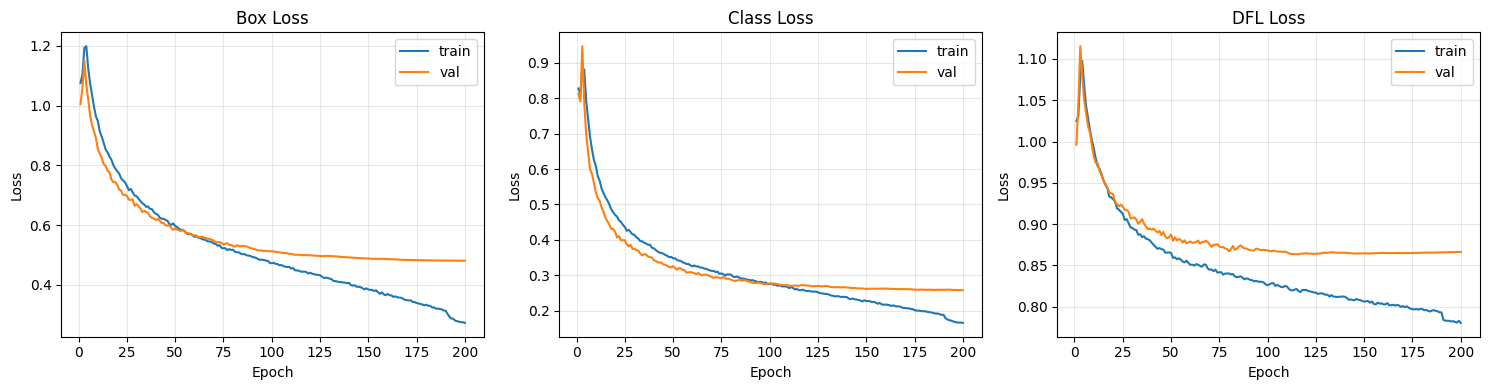

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

loss_pairs = [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/cls_loss", "val/cls_loss", "Class Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
]

for ax, (train_col, val_col, title) in zip(axes, loss_pairs):
    ax.plot(df["epoch"], df[train_col], label="train")
    ax.plot(df["epoch"], df[val_col], label="val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

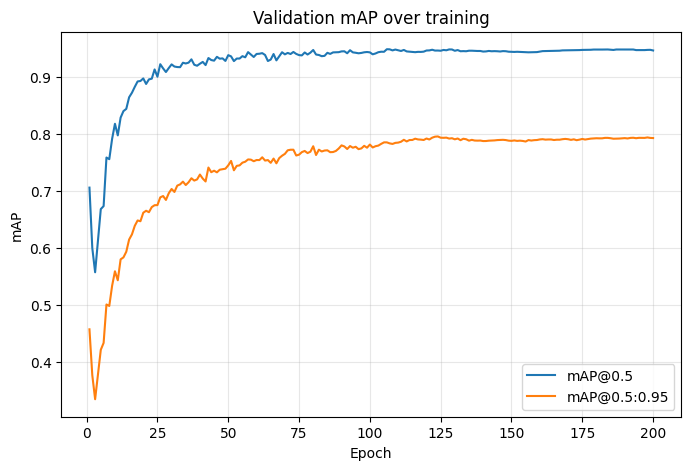

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
ax.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
ax.set_xlabel("Epoch")
ax.set_ylabel("mAP")
ax.set_title("Validation mAP over training")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [ ]:
import shutil
from pathlib import Path

drive_dest = Path("/content/drive/MyDrive/kitti_runs")
drive_dest.mkdir(parents=True, exist_ok=True)

src = ROOT / "runs"  # /content/kitti/runs

# copytree needs the destination to not already exist as a subfolder target,
# so copy into a named subfolder under drive_dest
shutil.copytree(src, drive_dest / "runs", dirs_exist_ok=True)

print(f"Copied {src} to {drive_dest / 'runs'}")

Copied /content/kitti/runs to /content/drive/MyDrive/kitti_runs/runs
